# FocusAI — CNN Training
Loads images from `data/raw/focused` and `data/raw/distracted`, trains a CNN, and saves the model to `models/focus_model.h5`.

In [6]:
import sys
from pathlib import Path

# Make sure project root is on the path
PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT = Path(PROJECT_ROOT).parent
print(PROJECT_ROOT)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

from src.utils.config import (
    IMG_SIZE, CHANNELS, CLASSES, DATA_RAW_PATH, MODEL_PATH
)

print("TensorFlow:", tf.__version__)
print("IMG_SIZE:", IMG_SIZE, "| CHANNELS:", CHANNELS, "| CLASSES:", CLASSES)

C:\Users\bruno\OneDrive\InsperAi\FocusAI
TensorFlow: 2.21.0
IMG_SIZE: (224, 224) | CHANNELS: 1 | CLASSES: ['focused', 'distracted']


## 1  Load images

In [7]:
DATA_DIR = PROJECT_ROOT / DATA_RAW_PATH
print("Looking for images in:", DATA_DIR.resolve())

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Data directory not found: {DATA_DIR.resolve()}\n"
        "Run the collection app first:  python main.py  (from the focusai/ folder)"
    )

images, labels = [], []

for label_idx, class_name in enumerate(CLASSES):
    class_dir = DATA_DIR / class_name
    jpg_files = list(class_dir.glob("*.jpg"))
    print(f"{class_name}: {len(jpg_files)} images")
    for img_path in jpg_files:
        raw = tf.io.read_file(str(img_path))
        img = tf.image.decode_jpeg(raw, channels=CHANNELS)
        img = tf.image.resize(img, IMG_SIZE)
        images.append(img.numpy())
        labels.append(label_idx)

X = np.array(images, dtype=np.float32) / 255.0
y = np.array(labels, dtype=np.int32)

print(f"\nDataset shape: {X.shape}  |  Labels: {y.shape}")

Looking for images in: C:\Users\bruno\OneDrive\InsperAi\FocusAI\data\raw
focused: 997 images
distracted: 1339 images

Dataset shape: (2336, 224, 224, 1)  |  Labels: (2336,)


## 2  Explore the data

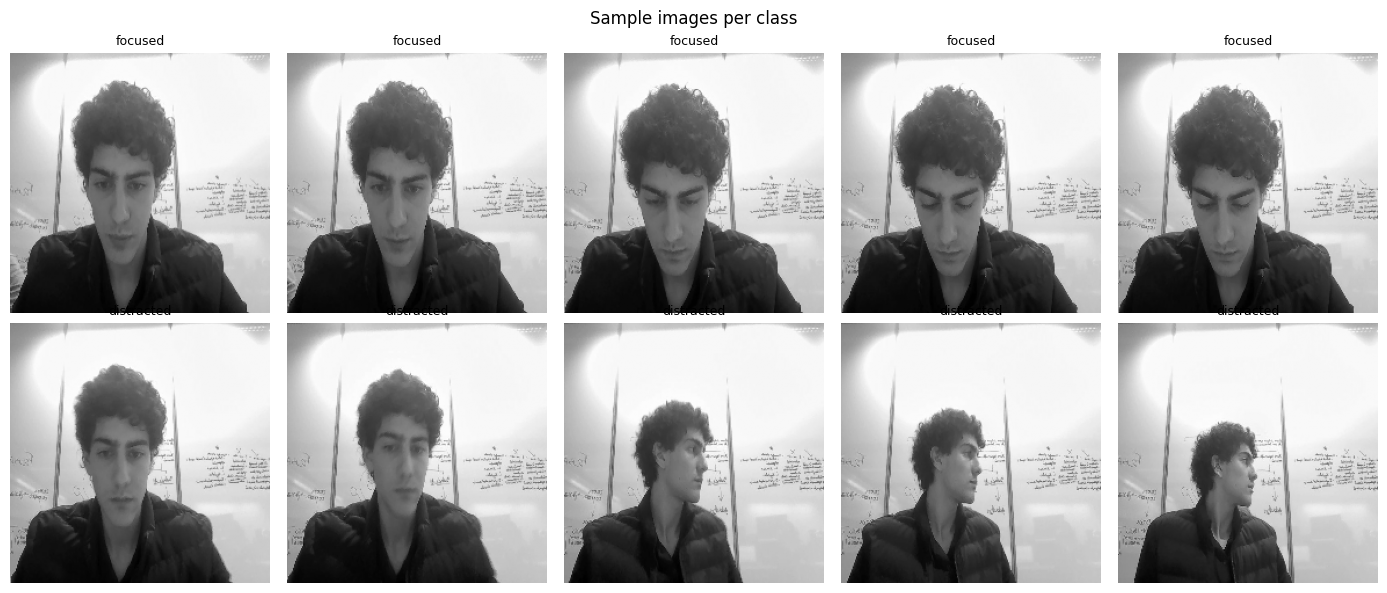

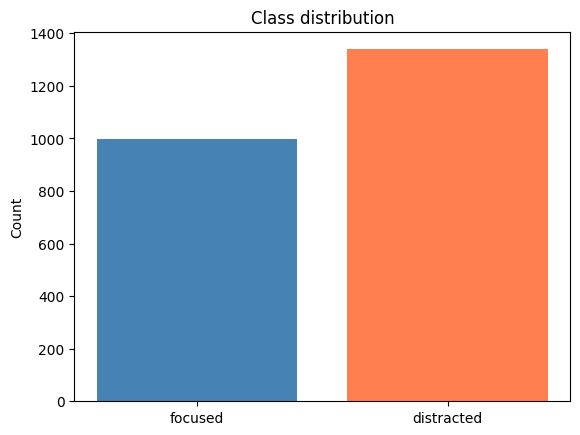

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for row, class_name in enumerate(CLASSES):
    idxs = np.where(y == row)[0][:5]
    for col, idx in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(X[idx].squeeze(), cmap="gray" if CHANNELS == 1 else None)
        ax.set_title(class_name, fontsize=9)
        ax.axis("off")
plt.suptitle("Sample images per class", fontsize=12)
plt.tight_layout()
plt.show()

unique, counts = np.unique(y, return_counts=True)
plt.bar([CLASSES[i] for i in unique], counts, color=["steelblue", "coral"])
plt.title("Class distribution")
plt.ylabel("Count")
plt.show()

In [ ]:
#def get_landmarks(image, detector, predictor):
#    """Return (68, 2) float32 landmarks for the largest face, or None.
#
#    Fast path: dlib detection with upsample=0. If that finds no face we fall
#    back to upsample=1 (the slower, more sensitive setting the old pipeline
#    used), so detection quality is never worse than before.
#    """
#    dets = detector(image, 0)
#    if len(dets) == 0:
#        dets = detector(image, 1)
#    if len(dets) == 0:
#        return None
#    det = max(dets, key=lambda d: d.width() * d.height())
#    shape = predictor(image, det)
#    lm = np.zeros((68, 2), dtype=np.float32)
#    for i in range(68):
#        lm[i] = (shape.part(i).x, shape.part(i).y)
#    return lm

## 3  Train / validation split

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}")

Train: 1868  |  Val: 468


## 4  Build the CNN

In [10]:
input_shape = (*IMG_SIZE, CHANNELS)

model = keras.Sequential([
    # Data augmentation (only active during training)
    layers.RandomFlip("horizontal", input_shape=input_shape),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),

    # Block 1
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),  # binary: 0=focused, 1=distracted
], name="focus_cnn")

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

c:\Users\bruno\OneDrive\InsperAi\FocusAI\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "focus_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

## 5  Train

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=7, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8282 - loss: 0.3823 - val_accuracy: 0.5726 - val_loss: 1.1551 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.8801 - loss: 0.2862 - val_accuracy: 0.5726 - val_loss: 1.5452 - learning_rate: 0.0010
Epoch 3/50
15/59 ━━━━━━━━━━━━━━━━━━━━ 2:09 3s/step - accuracy: 0.8816 - loss: 0.2787

KeyboardInterrupt: 

## 6  Training curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="val")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(history.history["accuracy"], label="train")
ax2.plot(history.history["val_accuracy"], label="val")
ax2.set_title("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

## 7  Evaluate on validation set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Val loss: {loss:.4f}  |  Val accuracy: {acc:.4f}")

y_pred = (model.predict(X_val, verbose=0) > 0.5).astype(int).flatten()

print("\n", classification_report(y_val, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(cmap="Blues")
plt.title("Confusion matrix — validation set")
plt.show()

## 8  Save the model

In [ ]:
model_path = PROJECT_ROOT / MODEL_PATH
model_path.parent.mkdir(parents=True, exist_ok=True)
model.save(str(model_path))
print("Model saved to:", model_path)

## 9  Quick inference demo

In [ ]:
def predict_image(img_path: str) -> str:
    """Return 'focused' or 'distracted' for a single image file."""
    raw = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(raw, channels=CHANNELS)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    prob = model.predict(img[np.newaxis, ...], verbose=0)[0][0]
    label = CLASSES[int(prob > 0.5)]
    return label, float(prob)

# Try on a random validation sample
sample_idx = np.random.choice(len(X_val))
prob = model.predict(X_val[sample_idx:sample_idx+1], verbose=0)[0][0]
predicted = CLASSES[int(prob > 0.5)]
actual = CLASSES[y_val[sample_idx]]

plt.imshow(X_val[sample_idx].squeeze(), cmap="gray" if CHANNELS == 1 else None)
plt.title(f"Predicted: {predicted} ({prob:.2%})  |  Actual: {actual}")
plt.axis("off")
plt.show()